# Project Overview & Aesthetic Setup
In an era of climate change, predicting renewable energy output is critical for grid stability. This notebook uses historical solar plant data and weather conditions to forecast power generation using a Long Short-Term Memory (LSTM) neural network.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from IPython.display import HTML, display

HTML("""
<style>
    .section-header { color: #f39c12; font-size: 24px; font-weight: bold; border-bottom: 2px solid #f39c12; padding-bottom: 5px; }
    .kpi-card { background-color: #fffde7; border-radius: 10px; padding: 20px; border: 1px solid #fbc02d; text-align: center; }
</style>
""")
# Global Settings
sns.set_theme(style="whitegrid")
plt.rc('figure', figsize=(15, 6))

# Data Loading & Preprocessing

In [4]:
# 1. Load and Clean
df = pd.read_csv('Plant_1_Generation_Data.csv',parse_dates=['DATE_TIME'],date_format='%d-%m-%Y %H:%M')
#df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'],date_format='%d-%m-%Y %H:%M')

# 2. Feature Scaling
data = df[['DC_POWER']].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# 3. Sequence Engineering
def create_sequences(data, seq_length):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length])
    return np.array(x), np.array(y)

SEQ_LENGTH = 24 
X, y = create_sequences(scaled_data, SEQ_LENGTH)

# 4. Train/Test Split
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Preprocessing Complete. Input Shape: {X_train.shape}")

Preprocessing Complete. Input Shape: (55003, 24, 1)


# Data Exploration (EDA)
Solar power is entirely dependent on the Diurnal Cycle (day vs. night) and Cloud Cover. Let's visualize the "Heartbeat" of a solar farm.

C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9728 (\N{BLACK SUN WITH RAYS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
 

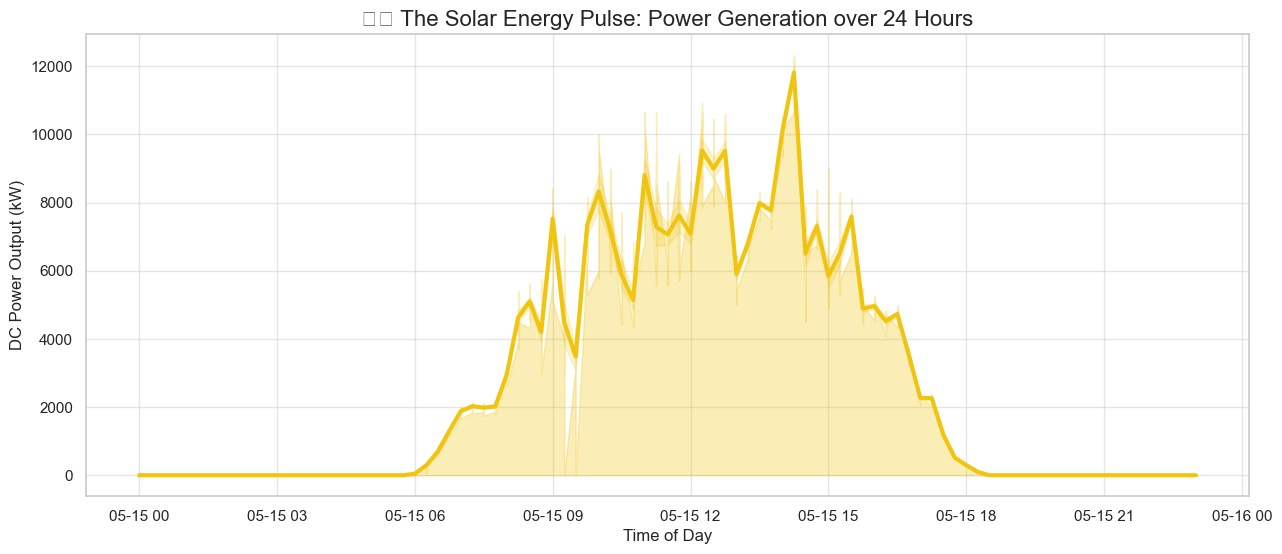

In [3]:
# Visualizing a single day to show the "Sun Curve"
single_day = df[df['DATE_TIME'].dt.date == df['DATE_TIME'].dt.date.iloc[0]]

plt.figure(figsize=(15, 6))
sns.lineplot(data=single_day, x='DATE_TIME', y='DC_POWER', color='#f1c40f', linewidth=3)
plt.fill_between(single_day['DATE_TIME'], single_day['DC_POWER'], color='#f1c40f', alpha=0.3)
plt.title("☀️ The Solar Energy Pulse: Power Generation over 24 Hours", fontsize=16)
plt.ylabel("DC Power Output (kW)")
plt.xlabel("Time of Day")
plt.show()

# The Model Architecture
For time-series forecasting, we use an LSTM. LSTMs are perfect here because they remember "State"—if it was cloudy 15 minutes ago, it’s likely still cloudy now.

In [4]:
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(SEQ_LENGTH, 1)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model 
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=1)

C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1547/1547 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - loss: 0.0055 - mae: 0.0333 - val_loss: 0.0011 - val_mae: 0.0142
Epoch 2/10
1547/1547 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 0.0022 - mae: 0.0208 - val_loss: 0.0010 - val_mae: 0.0147
Epoch 3/10
1547/1547 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - loss: 0.0022 - mae: 0.0200 - val_loss: 9.2998e-04 - val_mae: 0.0128
Epoch 4/10
1547/1547 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 0.0019 - mae: 0.0196 - val_loss: 9.3375e-04 - val_mae: 0.0142
Epoch 5/10
1547/1547 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - loss: 0.0018 - mae: 0.0189 - val_loss: 9.2211e-04 - val_mae: 0.0127
Epoch 6/10
1547/1547 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - loss: 0.0020 - mae: 0.0194 - val_loss: 9.3811e-04 - val_mae: 0.0124
Epoch 7/10
1547/1547 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 0.0021 - mae: 0.0198 - val_loss: 9.1247e-04 - val_mae: 0.0141
Epoch 8/10
1547/1547 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - loss: 0.0020 - mae: 0.0194 - val_loss: 9.8847e-04 - val_mae: 0.0146


# Performance Evaluation
We evaluate our model using Root Mean Squared Error (RMSE). A lower RMSE means our grid can rely more heavily on our predictions without backup gas generators.$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

In [5]:
# 1. Generate Predictions
predictions_scaled = model.predict(X_test)

# 2. Inverse Scaling
actual_values = scaler.inverse_transform(y_test.reshape(-1, 1))
predicted_values = scaler.inverse_transform(predictions_scaled)

# 3. Calculate Metrics
mae = mean_absolute_error(actual_values, predicted_values)
rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))

print(f"Evaluation Complete.\nMAE: {mae:.2f} kW\nRMSE: {rmse:.2f} kW")

430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
Evaluation Complete.
MAE: 203.16 kW
RMSE: 597.66 kW


# Visualizing the Results

C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9728 (\N{BLACK SUN WITH RAYS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


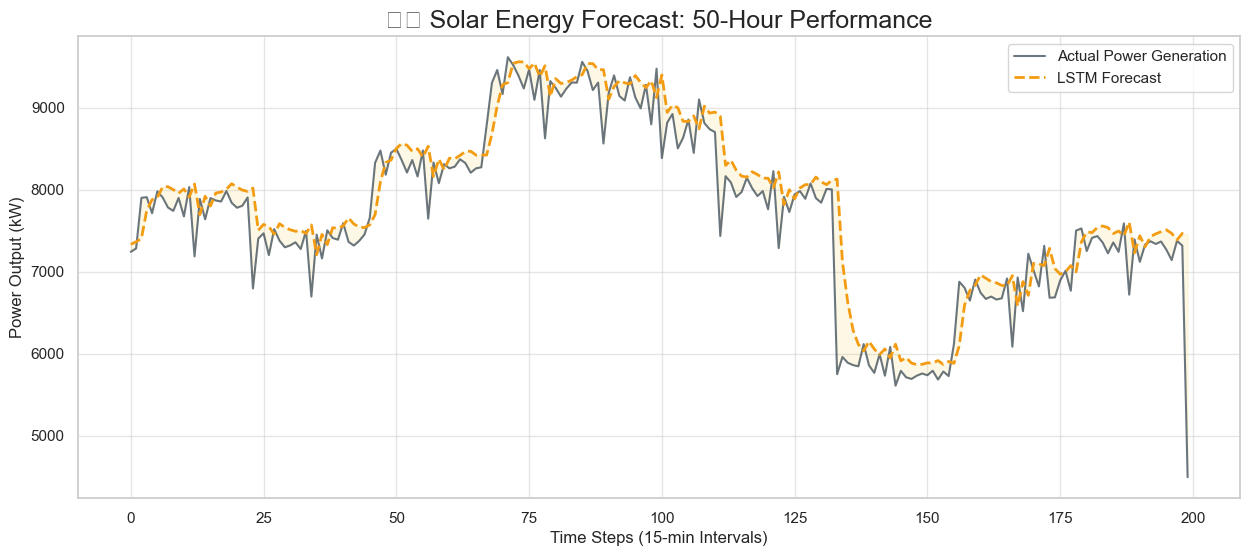

In [6]:
plt.figure(figsize=(15, 6))
plt.plot(actual_values[:200], label='Actual Power Generation', color='#2c3e50', alpha=0.7)
plt.plot(predicted_values[:200], label='LSTM Forecast', color='#f39c12', linestyle='--', linewidth=2)
plt.fill_between(range(200), actual_values[:200].flatten(), predicted_values[:200].flatten(), color='#f1c40f', alpha=0.1)

plt.title("☀️ Solar Energy Forecast: 50-Hour Performance", fontsize=18)
plt.xlabel("Time Steps (15-min Intervals)")
plt.ylabel("Power Output (kW)")
plt.legend(loc='upper right')
plt.show()

# Why This Matters (The "Viral" Close)
- Grid Stability: Better forecasts prevent blackouts.

- Economic Impact: Reduces the need for spinning reserves in the energy market.

- Scalability: This model can be adapted for Wind or Hydro power with minimal changes.

**Final Note: If you're interested in how Cloud Imagery (Computer Vision) could improve this model, let me know in the comments!**

<div class="insight-box"> <b>Did you find this helpful?</b> Renewable energy is the future! If you learned something about LSTMs or time-series today, please <b>Upvote</b> this notebook. It keeps me motivated to share more green-tech code! </div>